In [83]:
#https://github.com/mrdbourke/zero-to-mastery-ml/blob/master/section-2-data-science-and-ml-tools/introduction-to-scikit-learn.ipynb
#https://github.com/mrdbourke/zero-to-mastery-ml/blob/master/section-2-data-science-and-ml-tools/introduction-to-scikit-learn-video.ipynb
#https://github.com/mrdbourke/zero-to-mastery-ml/blob/master/section-2-data-science-and-ml-tools/scikit-learn-what-were-covering.ipynb

In [1]:
#Choosing the right estimator/algorithm for your problem

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [3]:
#👉 resolve a Regression Problem

from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()

housing_df = pd.DataFrame(housing["data"], columns=housing["feature_names"])
housing_df["target"] = pd.Series(housing["target"])
housing_df.head()

#column           what is it
#MedInc      median income in block group
#HouseAge    median house age in block group
#AveRooms    average number of rooms per household
#AveBedrms   average number of bedrooms per household

#In essence, each row is a different district in California (the data) and 
#we're trying to build a model to predict the median house value in that distract (the target/label) given a series of attributes about the houses in that district.

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
# How many samples?
len(housing_df)

20640

In [5]:
#Since we have data and labels, this is a SUPERVISED LEARNING problem.
#And since we're trying to predict a number, it's a REGRESSION PROBLEM.
#check w len(housing_df) quante rows ho nel dataframe...ne ho 20K ROWS.
#knowing these 3 things, we chek our Map of sklearn model(the cheat-sheet), and find out the model suggested is RIDGEREGRESSION  

# Import the Ridge model class from the linear_model module
from sklearn.linear_model import Ridge  #
from sklearn.model_selection import train_test_split  

# Setup random seed
np.random.seed(42)

# Split the data into features (X) and labels (y)
X = housing_df.drop("target", axis=1)
y = housing_df["target"]

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Institate and fit the model (on the training set)
model = Ridge()
model.fit(X_train, y_train)

# Check the score of the model (on the test set)
# The default score() metirc of regression aglorithms is R^2
model.score(X_test, y_test)

0.5758549611440131

In [6]:
#okey, the score isn't good. so check the MAP, and it suggested us to use the ENSEMBLE REGRESSOR
#Ensemble Regressor is another word for multiple models put together to make a decision.
#so we decide to use instead RANDOMFORESTREGRESSOR (combine a number of different decision trees, each one random from the other and make a prediction on a sample by averaging the result of each decision tree)

# Import the RandomForestRegressor model class from the ensemble module
from sklearn.ensemble import RandomForestRegressor

# Setup random seed
np.random.seed(42)

# Split the data into features (X) and labels (y)
X = housing_df.drop("target", axis=1)
y = housing_df["target"]

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Institate and fit the model (on the training set)
model = RandomForestRegressor()
model.fit(X_train, y_train)

# Check the score of the model (on the test set)
# The default score metirc of regression aglorithms is R^2
model.score(X_test, y_test)

0.8065734772187598

In [7]:
#good, this is a good score for our model!

In [8]:
#👉 resolve a Classification Problem

heart_disease = pd.read_csv("https://raw.githubusercontent.com/mrdbourke/zero-to-mastery-ml/master/data/heart-disease.csv") # load directly from URL (source: https://github.com/mrdbourke/zero-to-mastery-ml/blob/master/data/heart-disease.csv)
heart_disease.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [9]:
# How many samples are there?
len(heart_disease)

303

In [10]:
#ok, checking the MAP, we find out that it suggest us to use a LinearSCV model!

# Import LinearSVC from the svm module
from sklearn.svm import LinearSVC

# Setup random seed
np.random.seed(42)

# Split the data into X (features/data) and y (target/labels)
X = heart_disease.drop("target", axis=1)
y = heart_disease["target"]

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Instantiate and fit the model (on the training set)
clf = LinearSVC(max_iter=1000, # iterations on the data, 1000 is the default
                dual="auto") # dual="auto" chooses best parameters for the model automatically
clf.fit(X_train, y_train)

# Check the score of the model (on the test set)
clf.score(X_test, y_test)

0.8688524590163934

In [11]:
#good, now continue the MAP e try another model (we will follow the path in the MAP, skipping a few models (CHECK on ML_Udemy3.txt why!)).
#its suggested us to use a Ensemble Classifier.
#as before (x the 'regressor problem'), we don't use ensemble classifier but better we use the RANDOMFORESTCLASSIFIER

# Import the RandomForestClassifier model class from the ensemble module
from sklearn.ensemble import RandomForestClassifier

# Setup random seed
np.random.seed(42)

# Split the data into X (features/data) and y (target/labels)
X = heart_disease.drop("target", axis=1)
y = heart_disease["target"]

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Instantiate and fit the model (on the training set)
clf = RandomForestClassifier(n_estimators=100) # 100 is the default, but you could try 1000 and see what happens
clf.fit(X_train, y_train)

# Check the score of the model (on the test set)
clf.score(X_test, y_test)


0.8524590163934426

In [12]:
####okey, good score but not good as LinearCSV score. 
####now we do Hypermeter tuning(aggiustiamo le manopole del 'forno') on LinearCSV and also on RANDOMFORESTCLASSIFIER.

In [13]:
# Use a trained model to make predictions
# Compare predictions to truth
y_preds = clf.predict(X_test)
np.mean(y_preds == y_test)
#to .predict() must be passed X (data) in the same format the model was trained on.
#for example, if a model was trained on 10 features formatted in a certain way, predictions should be made on data with 10 features fortmatted in a certain way.
#It's standard practice to save these predictions to a variable named something like y_preds 
#for later comparison to y_test or y_true (usually same as y_test just another name).

np.float64(0.8524590163934426)

In [14]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_preds)  #🔥🔥

# Return probabilities rather than labels
clf.predict_proba(X_test[:5])

# Return labels
clf.predict(X_test[:5])

array([0, 1, 1, 0, 1])

In [15]:
# Compare the predictions to the truth
from sklearn.metrics import mean_absolute_error
mean_absolute_error(y_test, y_preds)

0.14754098360655737

In [16]:
# The highest value for the .score() method is 1.0, the lowest is 0.0
clf.score(X_train, y_train)

# Using cross_val_score()
from sklearn.model_selection import cross_val_score

cross_val_score(clf, X, y, cv=5) # cv = number of splits to test (5 by default)
clf_cross_val_score = np.mean(cross_val_score(clf, X, y, cv=5))

In [17]:
#######################type Classification model, evaluation metrics: 
#  Accuracy, 
#  Area under ROC curve, 
#  Confusion matrix,  #tells you if you're missing positives (dangerous!), if you're over-predicting positives
#  Classification report
#YOU ALWAYS MUST DO ALL X PERFECT analysis a 360° on everything and know everything!!

In [18]:
heart_disease = pd.read_csv("https://raw.githubusercontent.com/mrdbourke/zero-to-mastery-ml/master/data/heart-disease.csv") # load directly from URL (source: https://github.com/mrdbourke/zero-to-mastery-ml/blob/master/data/heart-disease.csv)
heart_disease.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [73]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)

X = heart_disease.drop("target", axis=1)
y = heart_disease["target"]

#w cross_val_score()
clf = RandomForestClassifier(n_estimators=100)
cross_val_score = cross_val_score(clf, X, y, cv=5)

#w score()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
clf = RandomForestClassifier()
clf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [74]:
###1.Accuracy

#w cross_val_score()
print(f"Heart Disease Classifier Cross-Validated Accuracy: {np.mean(cross_val_score) *100:.2f}%")

#w score()
print(f"Heart Disease Classifier Accuracy: {clf.score(X_test, y_test) * 100:.2f}%")

Heart Disease Classifier Cross-Validated Accuracy: 82.48%
Heart Disease Classifier Accuracy: 80.33%


In [72]:
###2.Area Under Receiver Operating Characteristic (ROC) Curve
#usually referred to as AUC for Area Under Curve and the curve they're talking about is the Receiver Operating Characteristic or ROC for short.
#if hear someone talking about AUC or ROC, it is what i explain you here.

#ROC curves are a comparison of true postive rate (tpr) versus false positive rate (fpr).
#True positive = model predicts 1 when truth is 1
#False positive = model predicts 1 when truth is 0
#True negative = model predicts 0 when truth is 0
#False negative = model predicts 0 when truth is 1

#now see how get from sklearn the information required for a ROC curve!

In [22]:
from sklearn.metrics import roc_curve

# Make predictions with probabilities
y_probs = clf.predict_proba(X_test)
   #each row is [probability of class 0, probability of class 1]

# Keep the probabilites of the positive class only
y_probs = y_probs[:, 1]   #: all rows, but get only second column (class = 1)

# Calculate fpr, tpr and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_probs) 
   #ROC curve:  y_test → true labels (0 or 1), y_probs → predicted probabilities
   #!! NEVER DO roc_curve(y_test, y_test) cioe test,test, bc y_pred = 0/1 labels → loses information
# Check the false positive rate
fpr   #fpr (False Positive Rate): among actual negatives, how many did we wrongly predict as positive?
      #formula:  FPR = FP / (FP + TN)
#tpr  #tpr (True Positive Rate): among actual positives, how many did we correctly predict?
      #formula:  TPR = TP / (TP + FN)
#thresholds:  Different probability cutoffs used. e.g. threshold = 0.9 → very strict  threshold = 0.1 → very loose. The ROC curve is built by testing many thresholds


#ok, but better get the Visual datas (using matplotlib)

array([0.        , 0.03448276, 0.03448276, 0.03448276, 0.03448276,
       0.03448276, 0.03448276, 0.06896552, 0.06896552, 0.06896552,
       0.10344828, 0.10344828, 0.13793103, 0.13793103, 0.13793103,
       0.20689655, 0.20689655, 0.20689655, 0.27586207, 0.37931034,
       0.37931034, 0.48275862, 0.48275862, 0.55172414, 0.55172414,
       1.        ])

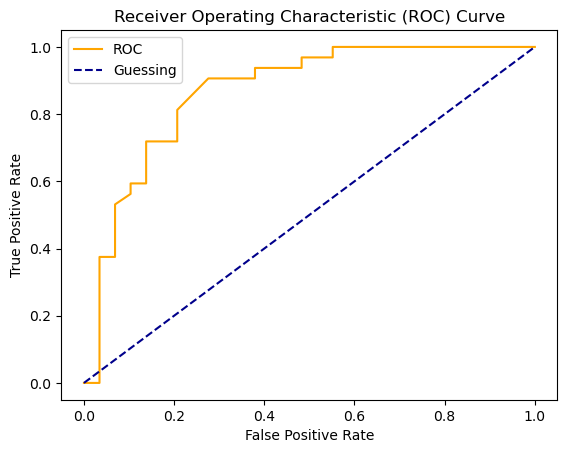

In [23]:
import matplotlib.pyplot as plt

def plot_roc_curve(fpr, tpr):   #fpr → x-axis   tpr → y-axis
    """
    Plots a ROC curve given the false positve rate (fpr) and 
    true postive rate (tpr) of a classifier.
    """
    # Plot ROC curve
    plt.plot(fpr, tpr, color='orange', label='ROC')
    # Plot line with no predictive power (baseline)
    plt.plot([0, 1], [0, 1], color='darkblue', linestyle='--', label='Guessing')
    # Customize the plot
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend()
    plt.show()
    
plot_roc_curve(fpr, tpr)

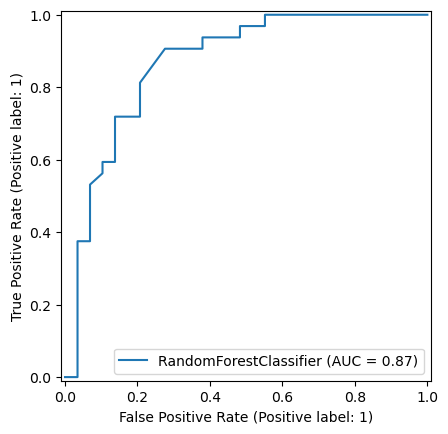

In [24]:
from sklearn.metrics import roc_auc_score   #AUC = area under the curve, 1.0 → perfect  0.5 → random  <0.5 → worse than random (very bad)

roc_auc_score_value = roc_auc_score(y_test, y_probs)  #y_test → true labels (0 or 1)   y_probs → predicted probabilities (NOT classes!)
roc_auc_score_value   #output a single number = AUC score. e.g. 87 means there is an 87% chance the model ranks a random positive higher than a random negative.

from sklearn.metrics import RocCurveDisplay   #built-in visualization tool from scikit-learn.
   #🔥🔥BETTER, instead of cumpute manually fpr and tpr, this: computes them + plots the ROC curve
roc_curve_display = RocCurveDisplay.from_estimator(estimator=clf, 
                                                   X=X_test, 
                                                   y=y_test)
       #.from_estimator() : uses your trained model (clf), calls predict_proba internally, computes ROC, plots it automatically

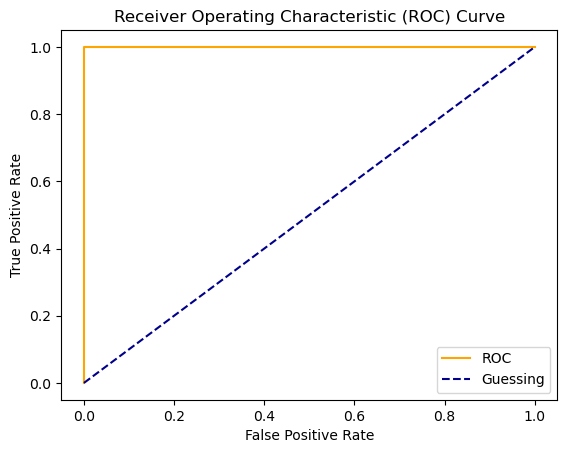

In [25]:
# Plot perfect ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_test)  #
plot_roc_curve(fpr, tpr)

In [26]:
# Perfect ROC AUC score
roc_auc_score(y_test, y_test)

1.0

In [70]:
###3.Confusion matrix
#a confusion matrix compares true labels vs predicted labels.
#is called 'confusion' bc it shows where the model is confused: mistakes between classes.

In [28]:
from sklearn.metrics import confusion_matrix

y_preds = clf.predict(X_test)

confusion_matrix(y_test, y_preds)   #compares real values → y_test and predicted values → y_preds

#return structure 
#[[TN, FP],
#[FN, TP]]
#che significa
#TN (True Negative)	predicted 0, actual 0
#FP (False Positive)	predicted 1, actual 0
#FN (False Negative)	predicted 0, actual 1
#TP (True Positive)	predicted 1, actual 1

#cioe quindi e.g.
#array([[23,  6],
#      [ 6, 26]])
#vuol dire:
#50 correct negatives
#10 false alarms
#5 missed positives
#35 correct positives

array([[23,  6],
       [ 6, 26]])

In [29]:
#visualizziamola in tabella
pd.crosstab(y_test,   #crosstab builds a table counting: how many times each combination occurs
            y_preds, 
            rownames=["Actual Label"], 
            colnames=["Predicted Label"])

Predicted Label,0,1
Actual Label,,
0,23,6
1,6,26


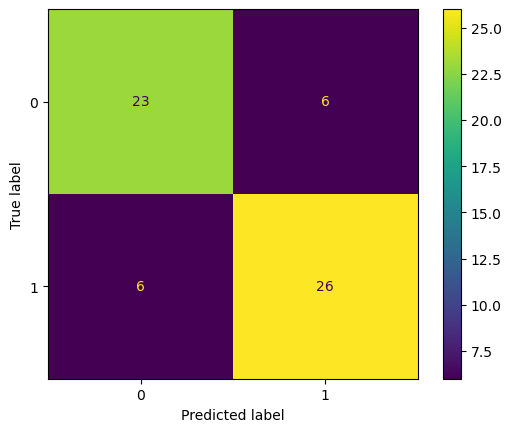

In [30]:
#BETTER do confusion matrix w sklearn!

from sklearn.metrics import ConfusionMatrixDisplay  #visualization utility from scikit-learn

ConfusionMatrixDisplay.from_estimator(estimator=clf, X=X_test, y=y_test);  #.from_estimator().  ok x quick checks.
    #remeber use X_test e y_test of the test, not trained X e y! otherhise overfitting(results will be too good, bc the datas was already trained (paths already builded) )
#builds the confusion matrix + plots it

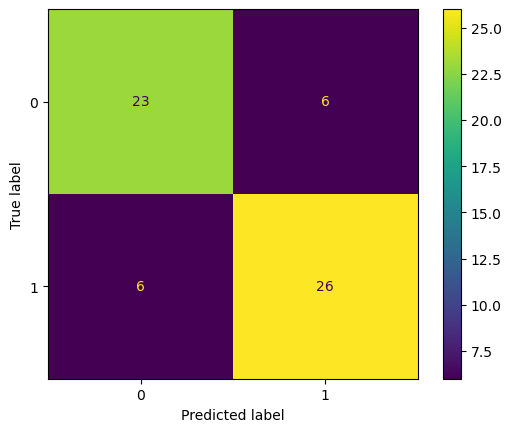

In [31]:
# Plot confusion matrix from predictions
ConfusionMatrixDisplay.from_predictions(y_true=y_test,   #.from_predictions(). #BETTER than 'from_estimator()', more flexible and explicit method x analysis
                                        y_pred=y_preds);
#takes already computed predictions, compares them to true labels, builds and plots the confusion matrix.

In [69]:
###4.Classification report
#is more so a collection of metrics rather than a single one. (always online on scikit-learn.org details).

from sklearn.metrics import classification_report

print(classification_report(y_test, y_preds))

#🔥Precision: “Out of all the times the model predicted POSITIVE, how many were actually correct?” e.g.model says 100 people have disease->but reality is only 80 actually have it, quindi Precision=0.8
#quindi high Precision = few false positives, model is careful when saying YES.
#🔥Recall: “Out of all actual positives, how many did the model find?” e.g.100 people have disease->model detects 80 of them, quindi Recall=0.8
#quindi high Recall = few false negatives, model catches most real cases
#recall is very important when missing a positive is dangerous e.g.disease detection / security systems / ect.
#🔥F1 Scroe: F1 = 2 * (precision * recall) / (precision + recall). is a balance between precision and recall, 🔥only high when both are good
#Support: number of samples in that class
#[
#Precision - Indicates the proportion of positive identifications (model predicted class 1) which were actually correct. A model which produces no false positives has a precision of 1.0.
#Recall - Indicates the proportion of actual positives which were correctly classified. A model which produces no false negatives has a recall of 1.0.
#F1 score - A combination of precision and recall. A perfect model achieves an F1 score of 1.0.
#Support - The number of samples each metric was calculated on.
#]

#0, 1 → your classes
#accuracy → overall performance
#macro avg → average (treat classes equally, ignores imbalance, good to see true performance per class)
#weighted avg → average (weighted by class size, favors majority class, can hide poor performance on minority class)
#[
#Accuracy - The accuracy of the model in decimal form. Perfect accuracy is equal to 1.0, in other words, getting the prediction right 100% of the time.
#Macro avg - Short for macro average, the average precision, recall and F1 score between classes. Macro avg doesn't take class imbalance into effect. So if you do have class imbalances (more examples of one class than another), you should pay attention to this.
#Weighted avg - Short for weighted average, the weighted average precision, recall and F1 score between classes. Weighted means each metric is calculated with respect to how many samples there are in each class. This metric will favour the majority class (e.g. it will give a high value when one class out performs another due to having more samples).
#]

ValueError: continuous is not supported

In [33]:
# Where precision and recall become valuable
#creiamo questo esempio dove con 10.000 people, only 1 has disease, models predicts: “no one has it”‼️‼️

disease_true = np.zeros(10000)
disease_true[0] = 1 # only one case

disease_preds = np.zeros(10000) # every prediction is 0

pd.DataFrame(classification_report(disease_true, 
                                   disease_preds, 
                                   output_dict=True,
                                   zero_division=0))

#🔥🔥Accuracy is a good measure to start with if all classes are balanced (e.g. same amount of samples which are labelled with 0 or 1)
#🔥🔥Precision and recall become more important when classes are imbalanced.
#If false positive predictions are worse than false negatives, aim for higher precision.
#If false negative predictions are worse than false positives, aim for higher recall.
##Resource: For more on precision and recall and the tradeoffs between them, I'd suggest going through the Scikit-Learn Precision-Recall guide.

,0.0,1.0,accuracy,macro avg,weighted avg
precision,0.99990,0.0,0.9999,0.499950,0.99980
recall,1.00000,0.0,0.9999,0.500000,0.99990
f1-score,0.99995,0.0,0.9999,0.499975,0.99985
support,9999.00000,1.0,0.9999,10000.000000,10000.00000


In [48]:
#######################type Regression model, evaluation metrics: 
#R^2 : measures how well your model explains the data, how much better your model is vs predicting the mean. e.g. 1=perfect predictions, 0=same as predicting mean, <0=worse than mean
    #"How good is my model compared to a dumb baseline?"
#MAE: meaning average error, easy to interpret. Lower = better!
    #"On average, how wrong am I?" “On average, how wrong is my model?”
#MSE: squares errors, penalizes big mistakes more, MSE punishes outliers heavily
    #"Am I making big mistakes?"
#[
#R^2 (pronounced r-squared) or coefficient of determination - Compares your models predictions to the mean of the targets. Values can range from negative infinity (a very poor model) to 1. For example, if all your model does is predict the mean of the targets, its R^2 value would be 0. And if your model perfectly predicts a range of numbers it's R^2 value would be 1. Higher is better.
#Mean absolute error (MAE) - The average of the absolute differences between predictions and actual values. It gives you an idea of how wrong your predictions were. Lower is better.
#Mean squared error (MSE) - The average squared differences between predictions and actual values. Squaring the errors removes negative errors. It also amplifies outliers (samples which have larger errors). Lower is better.
#]

In [35]:
# Import the RandomForestRegressor model class from the ensemble module
from sklearn.ensemble import RandomForestRegressor

# Setup random seed
np.random.seed(42)

# Split data into features (X) and labels (y)
X = housing_df.drop("target", axis=1)
y = housing_df["target"]

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Institate and fit the model (on the training set)
model = RandomForestRegressor()
model.fit(X_train, y_train);

In [44]:
###R^2 score
# Calculate the models R^2 score
model.score(X_test, y_test)  #🔥🔥For regression models, .score() returns always R^2 score!! 

0.8065734772187598

In [45]:
from sklearn.metrics import r2_score

# Fill an array with y_test mean
y_test_mean = np.full(len(y_test), y_test.mean())  #create a baseline model (VERY IMPORTANT!!)
  #y_test.mean() calc mean,  np.full(len(y_test), ...) creates an array of same length as y_tes, filled with that value y_test.mean()

r2_score(y_test, y_test_mean)  #the result 0, R² = 0 means “baseline model”

0.0

In [46]:
r2_score(y_test, y_test)  #here compari predictions = actual values. results is 1 bc no errors at all. R² = 1 means perfect model.

1.0

In [47]:
### MAE (Mean Absolute Error)

from sklearn.metrics import mean_absolute_error

y_preds = model.predict(X_test)
mae = mean_absolute_error(y_test, y_preds)  #MAE. This calculates the average error: subtracts prediction from actual, takes absolute value (no negatives), averages everything
mae

0.32659871732073664

In [40]:
df = pd.DataFrame(data={"actual values": y_test, 
                   "predictions": y_preds})

df

,actual values,predictions
20046,0.47700,0.493840
3024,0.45800,0.754940
15663,5.00001,4.928596
20484,2.18600,2.543160
9814,2.78000,2.331760
...,...,...
15362,2.63300,2.220380
16623,2.66800,1.947760
18086,5.00001,4.836378
2144,0.72300,0.717820


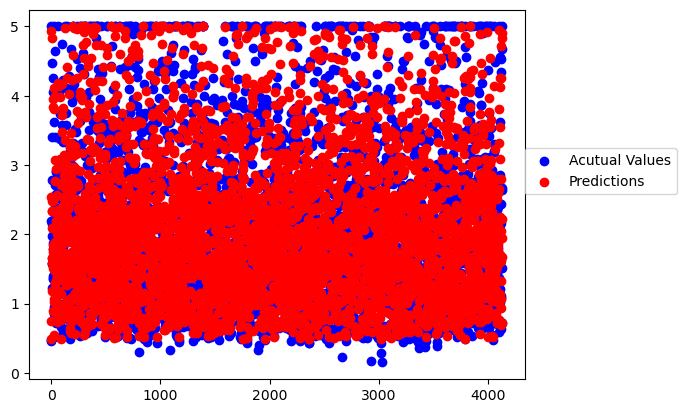

In [52]:
fig, ax = plt.subplots()  #fig→the whole figure  ax→the plotting area (axes)
x = np.arange(0, len(df), 1)  #this creates [0, 1, 2, 3, ..., N] (N = number of samples) This is just an index for plotting
ax.scatter(x, df["actual values"], c='b', label="Acutual Values") 
#Scatter plot (points):
#x-axis → index (0,1,2,...)
#y-axis → real values
#c='b' → blue points
ax.scatter(x, df["predictions"], c='r', label="Predictions")
ax.legend(loc=(1, 0.5));

#ideal case: red points overlap blue points, quindi perfect predictions.
#ma in realta quasi sempre vedi  some points close → good predictions  some far → errors
#CON LA VISUALIZZAZIONE vedi immediatamente where model fails, patterns in errors,outliers!!

In [54]:
###MSE (Mean Squared Error)

from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_preds)  #MSE
  #compute the error (error = y_true - y_pred) -> Square the error (error²) -> Take the average of all squared errors, return il value.
mse

0.2534678520824551

In [55]:
###########################Scoring param

from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)

X = heart_disease.drop("target", axis=1)
y = heart_disease["target"]

clf = RandomForestClassifier(n_estimators=100)

In [56]:
np.random.seed(42)
cv_acc = cross_val_score(clf, X, y, cv=5)
cv_acc

array([0.81967213, 0.90163934, 0.83606557, 0.78333333, 0.78333333])

In [57]:
# Cross-validated accuracy
print(f"The cross-validated accuracy is: {np.mean(cv_acc)*100:.2f}%")

The cross-validated accuracy is: 82.48%


In [58]:
np.random.seed(42)
cv_acc = cross_val_score(clf, X, y, cv=5, scoring="accuracy")
print(f"The cross-validated accuracy is: {np.mean(cv_acc)*100:.2f}%")

The cross-validated accuracy is: 82.48%


In [59]:
np.random.seed(42)
cv_precision = cross_val_score(clf, X, y, cv=5, scoring="precision")
print(f"The cross-validated precision is: {np.mean(cv_precision):.2f}")

The cross-validated precision is: 0.83


In [60]:
np.random.seed(42)
cv_recall = cross_val_score(clf, X, y, cv=5, scoring="recall")
print(f"The cross-validated recall is: {np.mean(cv_recall):.2f}")

The cross-validated recall is: 0.85


In [61]:
np.random.seed(42)
cv_f1 = cross_val_score(clf, X, y, cv=5, scoring="f1")
print(f"The cross-validated F1 score is: {np.mean(cv_f1):.2f}")

The cross-validated F1 score is: 0.84


In [62]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor

np.random.seed(42)

X = housing_df.drop("target", axis=1)
y = housing_df["target"]

model = RandomForestRegressor(n_estimators=100)

In [63]:
%%time 
np.random.seed(42)
cv_r2 = cross_val_score(model, X, y, cv=5, scoring="r2")
print(f"The cross-validated R^2 score is: {np.mean(cv_r2):.2f}")

The cross-validated R^2 score is: 0.65
CPU times: total: 40.5 s
Wall time: 43.1 s


In [64]:
%%time
np.random.seed(42)
cv_mae = cross_val_score(model, X, y, cv=5, scoring="neg_mean_absolute_error")
print(f"The cross-validated MAE score is: {np.mean(cv_mae):.2f}")

The cross-validated MAE score is: -0.47
CPU times: total: 40.3 s
Wall time: 42.6 s


In [65]:
np.random.seed(42)
cv_mse = cross_val_score(model, X, y, cv=5, scoring="neg_mean_squared_error")
print(f"The cross-validated MSE score is: {np.mean(cv_mse):.2f}")

The cross-validated MSE score is: -0.43


In [66]:
####################### Classification problem, functions: 
                        #sklearn.metrics.accuracy_score, sklearn.metrics.precision_score
                        #sklearn.metrics.recall_score, sklearn.metrics.f1_score

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

np.random.seed(42)

X = heart_disease.drop("target", axis=1)
y = heart_disease["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

clf = RandomForestClassifier(n_estimators=100)
clf.fit(X_train, y_train)

# Make predictions
y_preds = clf.predict(X_test)

# Evaluate the classifier
print("Classifier metrics on the test set:")
print(f"Accuracy: {accuracy_score(y_test, y_preds) * 100:.2f}%")
print(f"Precision: {precision_score(y_test, y_preds):.2f}")
print(f"Recall: {recall_score(y_test, y_preds):.2f}")
print(f"F1: {f1_score(y_test, y_preds):.2f}")

Classifier metrics on the test set:
Accuracy: 85.25%
Precision: 0.85
Recall: 0.88
F1: 0.86


In [67]:
####################### Regression problem, functions: 
                        #sklearn.metrics.r2_score, sklearn.metrics.mean_absolute_error, sklearn.metrics.mean_squared_error

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

np.random.seed(42)

X = housing_df.drop("target", axis=1)
y = housing_df["target"]

X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=0.2)

model = RandomForestRegressor(n_estimators=100, 
                              n_jobs=-1)
model.fit(X_train, y_train)

# Make predictions
y_preds = model.predict(X_test)

# Evaluate the model
print("Regression model metrics on the test set:")
print(f"R^2: {r2_score(y_test, y_preds):.2f}")
print(f"MAE: {mean_absolute_error(y_test, y_preds):.2f}")
print(f"MSE: {mean_squared_error(y_test, y_preds):.2f}")

Regression model metrics on the test set:
R^2: 0.81
MAE: 0.33
MSE: 0.25


In [75]:
################################5. Improving model predictions through experimentation (hyperparameter tuning)....

In [76]:
################################ Pipeline, for Regression problem

# data = pd.read_csv("../data/car-sales-extended-missing-data.csv") # load from local directory
data = pd.read_csv("https://raw.githubusercontent.com/mrdbourke/zero-to-mastery-ml/master/data/car-sales-extended-missing-data.csv") # load directly from URL
data.head()

,Make,Colour,Odometer (KM),Doors,Price
0,Honda,White,35431.0,4.0,15323.0
1,BMW,Blue,192714.0,5.0,19943.0
2,Honda,White,84714.0,4.0,28343.0
3,Toyota,White,154365.0,4.0,13434.0
4,Nissan,Blue,181577.0,3.0,14043.0


In [77]:
data.dtypes

Make                 str
Colour               str
Odometer (KM)    float64
Doors            float64
Price            float64
dtype: object

In [78]:
data.isna().sum()

Make             49
Colour           50
Odometer (KM)    50
Doors            50
Price            50
dtype: int64

In [79]:
# Getting data ready
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# Modelling
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV

# Setup random seed
import numpy as np
np.random.seed(42)

# Import data and drop the rows with missing labels
data = pd.read_csv("https://raw.githubusercontent.com/mrdbourke/zero-to-mastery-ml/master/data/car-sales-extended-missing-data.csv")
data.dropna(subset=["Price"], inplace=True)

# Define different features and transformer pipelines
categorical_features = ["Make", "Colour"]
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))])

door_feature = ["Doors"]
door_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value=4))])

numeric_features = ["Odometer (KM)"]
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean"))
])

# Setup preprocessing steps (fill missing values, then convert to numbers)
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, categorical_features),
        ("door", door_transformer, door_feature),
        ("num", numeric_transformer, numeric_features)])

# Create a preprocessing and modelling pipeline
model = Pipeline(steps=[("preprocessor", preprocessor),
                        ("model", RandomForestRegressor(n_jobs=-1))])

# Split data
X = data.drop("Price", axis=1)
y = data["Price"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Fit and score the model
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.22188417408787875

In [82]:
%%time

#It's possible to GridSearchCV or RandomizedSearchCV with a Pipeline.
#The main difference is when creating a hyperparameter grid, you have to add a prefix to each hyperparameter (see the documentation for RandomForestRegressor for a full list of possible hyperparameters to tune).
#The prefix is the name of the Pipeline step you'd like to alter, followed by two underscores.
#e.g. to adjust n_estimators of "model" in the Pipeline, you'd use: "model__n_estimators" (note the double underscore after model__ at the start).

# Using grid search with pipeline
pipe_grid = {
    "preprocessor__num__imputer__strategy": ["mean", "median"], # note the double underscore after each prefix "preprocessor__"
    "model__n_estimators": [100, 1000],
    "model__max_depth": [None, 5],
    "model__max_features": ["sqrt"],
    "model__min_samples_split": [2, 4]
}

gs_model = GridSearchCV(model, pipe_grid, cv=5, verbose=2)
gs_model.fit(X_train, y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_split=2, model__n_estimators=100, preprocessor__num__imputer__strategy=mean; total time=   0.1s
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_split=2, model__n_estimators=100, preprocessor__num__imputer__strategy=mean; total time=   0.1s
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_split=2, model__n_estimators=100, preprocessor__num__imputer__strategy=mean; total time=   0.1s
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_split=2, model__n_estimators=100, preprocessor__num__imputer__strategy=mean; total time=   0.1s
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_split=2, model__n_estimators=100, preprocessor__num__imputer__strategy=mean; total time=   0.1s
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_sampl

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...(n_jobs=-1))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [None, 5], 'model__max_features': ['sqrt'], 'model__min_samples_split': [2, 4], 'model__n_estimators': [100, 1000], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for eac

In [81]:
# Score the best model
gs_model.score(X_test, y_test)

0.2848784564026805